# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

- Автор: Шлыков Алексей
- Дата: 06.03.2025

### Цели и задачи проекта
Построить модель бинарной классификации, которая спрогнозирует вероятность оттока каждого клиента в следующем месяце для сервиса по доставке элитного кофе. Подготовить модель к внедрению в промышленную эксплуатацию.

### Содержание проекта
1. Подготовка среды и библиотек
2. Первичный анализ данных
    - 2.1. Знакомство с данными
    - 2.2. Описание целевой переменной
    - 2.3. Описание признаков
    - 2.4. Обработка пропущенных значений
    - 2.5. Анализ категориальных признаков
    - 2.6. Исследование корреляций между признаками
3. Предобработка данных
4. Обучение модели
5. Создание новых признаков
6. Эксперименты с гиперпараметрами
7. Подготовка финальной модели
8. Итоговый отчет по проекту 
9. Сохранение модели для продакшена

### 1. Подготовка среды и библиотек

In [1]:
# Импортируем необходимые библиотеки
import warnings

import joblib
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from phik import phik_matrix
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (auc, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (MinMaxScaler, OneHotEncoder, RobustScaler,
                                   StandardScaler)

In [2]:
# Загружаем данные
df = pd.read_csv("https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv", sep=',', decimal='.')

In [3]:
# Проверим, что загрузка прошла успешно
df.head(5)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


Данные успешно загружены, названия и содержимое столбцов соответствует описанию.

## Этап 2. Первичный анализ данных

**2.1. Знакомство с данными**

In [4]:
# Создаем функцию для первичного ознакомления с данными
def watchdata(data):
    print('Подсчет абсолютного количества пропусков:') # Считаем пропуски
    display(data.isna().sum().sort_values(ascending=False)) 
    print('Всего пропусков:', data.isna().sum().sum())
    print('-'*100)
    
    print('Подсчет относительного количества пропусков:')
    display(data.isna().mean().sort_values(ascending=False)*100) # Считаем долю пропусков в процентах
    print('-'*100)
    
    for element in data.columns:
        if type(data[element]) == object:
            data[column] = data[column].str.lower().str.strip().str.replace() # Приводим категориальные колонки к snake_case
    
    print('Подсчет дубликатов:')              
    dupl_count = data.duplicated().sum() # Подсчитываем количество полных дубликатов       
    if dupl_count > 0:
        print(f'Количество дублей в датафрейме - {dupl_count}')
    else:
        print('Явные дубликаты отсутствуют')
    print('-'*100)
    
    print('Статистические метрики столбцов с численными данными:')             
    display(data.describe()) # Выводим статистические метрики
    print('-'*100)
    
    print('Общая информация по датафрейму:')
    display(data.info()) # Выводим общую информацию 
    
    return print('-'*100)

In [5]:
# Выводим информацию о датасете
watchdata(df)

Подсчет абсолютного количества пропусков:


seasonal_menu_tried         989
days_since_last_order       945
total_spent_last_week       944
subscription_status         938
app_opens_per_week          896
review_rating_last_1        857
median_order_value          831
days_since_last_promo       731
app_crashes_last_month      721
review_rating_last_10       693
coffee_bean_origin          682
seasons                     679
milk_preference             668
coffee_preference_change    610
order_frequency_month       600
avg_order_value             583
notifications_enabled       537
last_drink_size             504
discount_usage_rate         397
order_frequency_week        388
phone_type                  336
total_spent_last_month      294
last_coffee_type            258
preferred_roast             116
geo_location                110
user_id                       0
churn                         0
dtype: int64

Всего пропусков: 15307
----------------------------------------------------------------------------------------------------
Подсчет относительного количества пропусков:


seasonal_menu_tried         9.464115
days_since_last_order       9.043062
total_spent_last_week       9.033493
subscription_status         8.976077
app_opens_per_week          8.574163
review_rating_last_1        8.200957
median_order_value          7.952153
days_since_last_promo       6.995215
app_crashes_last_month      6.899522
review_rating_last_10       6.631579
coffee_bean_origin          6.526316
seasons                     6.497608
milk_preference             6.392344
coffee_preference_change    5.837321
order_frequency_month       5.741627
avg_order_value             5.578947
notifications_enabled       5.138756
last_drink_size             4.822967
discount_usage_rate         3.799043
order_frequency_week        3.712919
phone_type                  3.215311
total_spent_last_month      2.813397
last_coffee_type            2.468900
preferred_roast             1.110048
geo_location                1.052632
user_id                     0.000000
churn                       0.000000
d

----------------------------------------------------------------------------------------------------
Подсчет дубликатов:
Явные дубликаты отсутствуют
----------------------------------------------------------------------------------------------------
Статистические метрики столбцов с численными данными:


,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


----------------------------------------------------------------------------------------------------
Общая информация по датафрейму:
<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    

None

----------------------------------------------------------------------------------------------------


**Промежуточный вывод:**
- Загружен датасет, состоящий из 10450 строк, 27 столбцов. 
- Пропуски присутствуют во всех столбцах кроме `user_id` и `churn`.
- Доля пропусков составляет от 1 до 9.5%.
- Все данные типа object приведены к виду snake_case.
- Явные дубликаты отсутствуют.
- Предварительный осмотр статистических метрик указывает на наличии выбросов в большинстве столбцов и правом ассиметричном распределении.
- В некоторых столбцах замечены нереалистичные отрицательные значения.

**2.2. Описание целевой переменной**

Целевая представлена столбцом churn, это бинарный признак, содержащий информацию об оставшихся и ушедших пользователей.

In [6]:
# Посмотрим подробнее на столбец.
df['churn'].value_counts()

churn
0    9821
1     629
Name: count, dtype: int64

Видим, что классы распределены неравномерно. Положительный класс (ушедшие пользователи) составляет ~ 6.4% от общего числа пользователей.

**2.3 Описание признаков**


**Представленные признаки можно разделить на условные несколько групп:**
- Признаки, описывающие частоту совершения заказов ('days_since_last_order', 'order_frequency_month', 'order_frequency_week')


- Признаки, касающиеся трат пользователя ('avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate')   


- Вкусовые предпочтения клиента ('last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'coffee_preference_change')


- Признаки, описывающие поведение клиента в приложении ('subscription_status', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo')


- Признаки, содержащие данные о самом клиенте ('user_id', 'phone_type', 'geo_location', 'seasons')


- Время года и сезонные предложения ('seasons', 'seasonal_menu_tried'). Значение признака 'seasons' следует уточнить у заказчика: если данные собраны за последний месяц, то почему в столбце присутствуют разные времена года?


- Столбец с целевой переменной 'churn', содержащую информацию, престал ли пользователь пользоваться сервисом.

**Какие признаки не понадобятся для построения модели:**


- Идентификационные данные пользователя'user_id':  это техническая информация.


- Решение по удалению или оставлению признаков на основе их полезности мы будем принимать после построения корреляционной матрицы.

In [7]:
# Удаляем колнку user_id
df = df.drop(columns='user_id')

**2.4 Обработка пропусков**


Постараемся установить природу пропусков в числовых колонках. Гипотеза: если пропуски не эквивалентны 0, то в колонках должны присутствовать нулевые значения помимо пропусков.

In [8]:
# Узнаем количество нулевых значений
for column in df.columns:
    if df[column].dtype == 'float64':
        print(f"Колонка: {column}")
        zero_values = df.loc[df[column] == 0]
        zero_count = len(zero_values)
        print(f'Нулевых значений: {zero_count}')

Колонка: days_since_last_order
Нулевых значений: 1763
Колонка: order_frequency_month
Нулевых значений: 0
Колонка: order_frequency_week
Нулевых значений: 0
Колонка: avg_order_value
Нулевых значений: 0
Колонка: median_order_value
Нулевых значений: 0
Колонка: total_spent_last_month
Нулевых значений: 0
Колонка: total_spent_last_week
Нулевых значений: 0
Колонка: discount_usage_rate
Нулевых значений: 0
Колонка: seasonal_menu_tried
Нулевых значений: 2827
Колонка: app_opens_per_week
Нулевых значений: 121
Колонка: notifications_enabled
Нулевых значений: 2448
Колонка: review_rating_last_10
Нулевых значений: 0
Колонка: review_rating_last_1
Нулевых значений: 0
Колонка: app_crashes_last_month
Нулевых значений: 3571
Колонка: days_since_last_promo
Нулевых значений: 628
Колонка: coffee_preference_change
Нулевых значений: 7946


- Гипотеза подтверждена частично: в колонках days_since_last_order, seasonal_menu_tried, app_opens_per_week, notifications_enabled, app_crashes_last_month, days_since_last_promo, coffee_preference_change присутствуют нулевые значения, скорее всего пропуски в них связаны с другими причинами (MCAR)


- В колонках order_frequency_month, order_frequency_week, avg_order_value, median_order_value, total_spent_last_month, discount_usage_rate, review_rating_last_10, review_rating_last_1 нулевые значения отсутствуют. Это возможно, если исходить из того, что каждый пользователь сделал хотя бы один заказ. В таком случае, в этих колонках пропуски также можно отнести к категории MCAR.


- Исходя из сделанных выводов, мы будем придерживаться единой стратегии в обработке пропусков: оставить на данном этапе без измененений, заменить на средниее значения на этапе предобработки.


- Небольшое количество пропусков в категориальных колонках last_coffee_type, preferred_roast, milk_preference, coffee_bean_origin, last_drink_size, subscription_status, seasons, phone_type заменим на значение-индикатор вида "нет данных". 

In [9]:
cat_columns = ['last_coffee_type',
         'preferred_roast',
         'milk_preference',
         'coffee_bean_origin',
         'last_drink_size',
         'subscription_status',
         'seasons',
         'phone_type']
 # Заменяем пропуски на значение индикатор
for column in cat_columns:
    if column in df.columns:
        df[column] = df[column].fillna('нет данных')

В ходе предварительного знакомства с данными, обнаружены отрицательные значения в нескольких столбцах. Скорее всего имеет место ошибка ввода данных. Подсчитаем их количество.

In [10]:
# Узнаем количество отрицательных значений
for column in df.columns:
    if df[column].dtype == 'float64':
        print(f"Колонка: {column}")
        neg_values = df.loc[df[column] < 0]
        neg_count = len(neg_values)
        print(f'  Отрицательных значений: {neg_count}')
        

Колонка: days_since_last_order
  Отрицательных значений: 0
Колонка: order_frequency_month
  Отрицательных значений: 0
Колонка: order_frequency_week
  Отрицательных значений: 83
Колонка: avg_order_value
  Отрицательных значений: 2
Колонка: median_order_value
  Отрицательных значений: 2
Колонка: total_spent_last_month
  Отрицательных значений: 2
Колонка: total_spent_last_week
  Отрицательных значений: 171
Колонка: discount_usage_rate
  Отрицательных значений: 0
Колонка: seasonal_menu_tried
  Отрицательных значений: 0
Колонка: app_opens_per_week
  Отрицательных значений: 0
Колонка: notifications_enabled
  Отрицательных значений: 0
Колонка: review_rating_last_10
  Отрицательных значений: 0
Колонка: review_rating_last_1
  Отрицательных значений: 6
Колонка: app_crashes_last_month
  Отрицательных значений: 0
Колонка: days_since_last_promo
  Отрицательных значений: 0
Колонка: coffee_preference_change
  Отрицательных значений: 0


В контексте данных эти значения нереалистичны. Поменяем отрицаетльные значения на NaN, чтобы в дальнейшем обработать их вместе с остальными пропусками.

In [11]:
# Проведем замену отрицательных значений на пропуски
for column in df.columns:
    if df[column].dtype == 'float64':
        df.loc[df[column] < 0, column] = np.nan

Как мы уже отмечали раннее, доля пропусков в некоторых колонках доходит до 9.5%. Это значительный объем данных для того, чтобы их удалить. На этапе предобработки данных мы будем придерживаться стратегии замены пропусков на средние 

**2.5 Категориальные признаки**

Категориальные признаки представлены столбцами 'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status' (эти признаки характеризуют вкусовые предпочтения пользователей) и столбцами 'season', 'phone_type', 'geo_location' (время года, устройство пользователя и территориальное расположение пользователя).

In [12]:
df['last_drink_size'].dtype

<StringDtype(storage='python', na_value=nan)>

In [13]:
# Рассмотрим внимательнее категориальные признаки
for column in df.columns:
    if df[column].dtype == 'str':
        print(df[column].value_counts())

last_coffee_type
arabica       6134
robusta       2524
blend         1534
нет данных     258
Name: count, dtype: int64
preferred_roast
medium        3458
light         3453
dark          3423
нет данных     116
Name: count, dtype: int64
milk_preference
whole         2876
oat           1982
almond        1483
skim          1451
none          1015
soy            975
нет данных     668
Name: count, dtype: int64
coffee_bean_origin
ethiopia      1690
kenya         1646
vietnam       1635
guatemala     1621
brazil        1596
colombia      1580
нет данных     682
Name: count, dtype: int64
last_drink_size
medium        4925
large         2997
small         2024
нет данных     504
Name: count, dtype: int64
subscription_status
none          3803
basic         2862
premium       1923
нет данных     938
pro            924
Name: count, dtype: int64
seasons
spring        2507
autumn        2433
winter        2423
summer        2408
нет данных     679
Name: count, dtype: int64
phone_type
android    

Содержание всех категориальных признаков соответствует описанию. Кодировать мы будем все признаки, которые решим оставить в датасете после построения корреляционной матрицы. Кодирование необходима, так как линейные модели могут работать только с числами.


Мы будем использовать стратегию OneHotEncoding.

**Генерация новых признаков:**
- Комбинация технических проблем и низких оценок: если app_crashes_last_month > 2 и review_rating_last_1 < 3. Сбои + плохой отзыв = почти гарантированный уход.

- Комбинация редкости заказов и высокого чека: avg_order_value / (order_frequency_week).

- Резкое ухудшение оценки может быть триггером оттока: review_rating_last_10 - review_rating_last_1 (если разница большая отрицательная — клиент разочарован последним заказом).

- app_opens_per_week / order_frequency_week (активность в приложении на заказ).

### 2.6. Анализ выбросов

Так как в датасете достаточно много признаков, мы поделим их на несколько групп для более наглядной визуализации:количество заказов за период времени и время с предыдущего заказа; данные о тратах пользователей; данные о рейтингах; данные о пользовательской активности; данные о сбоях в работе приложения.

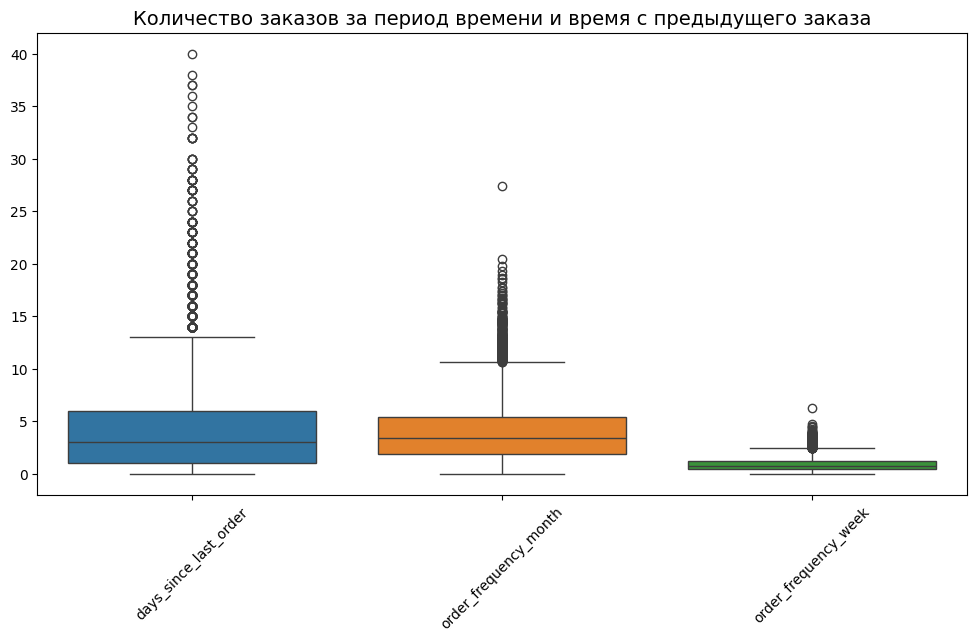

In [14]:
# Визуализируем распределение: количество заказов за период времени и время с предыдущего заказа
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['days_since_last_order', 'order_frequency_month', 'order_frequency_week']])
plt.title('Количество заказов за период времени и время с предыдущего заказа', fontsize=14)
plt.xticks(rotation=45)
plt.show()

Здесь присутствуют правые хвосты без сильных аномалий, распределение выглядит логично. Большинство пользоваетелей деляют повторный заказ в течение 6 дней, хотя в некоторых случаях промежуток доходит до 40 дней. Эти данные важны, так как возможно пользователи редко совершающие заказы более склонны к уходу. 

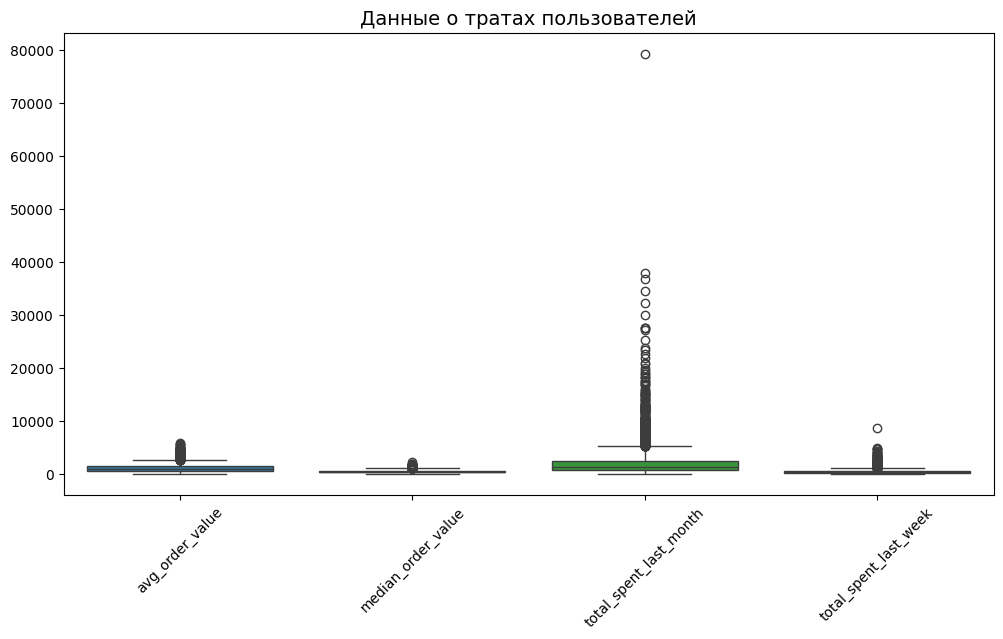

In [15]:
# Визуализируем распределение: данные о тратах пользователей
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week']])
plt.title('Данные о тратах пользователей', fontsize=14)
plt.xticks(rotation=45)
plt.show()

**!!!!**

Наблюдаем длинный правый хвост у признака 'total_spent_last_month' (до 40тыс. рублей в месяц), это нормально с учетом возможно присутствия мелкоптовых клиентов. Присутствует сильное аномальное значение (80тыс. расход за месяц), оно не вписывается в общую картину, его стоит отфильтровать, так как аномалии могут сильно влиять на качество обучения модели.

Выбросы в столбцах 'avg_order_value', 'median_order_value', 'total_spent_last_week' доходят до 10тыс. рублей, что также реалистично с учетом мелкооптовых икорпоративных клиентов.


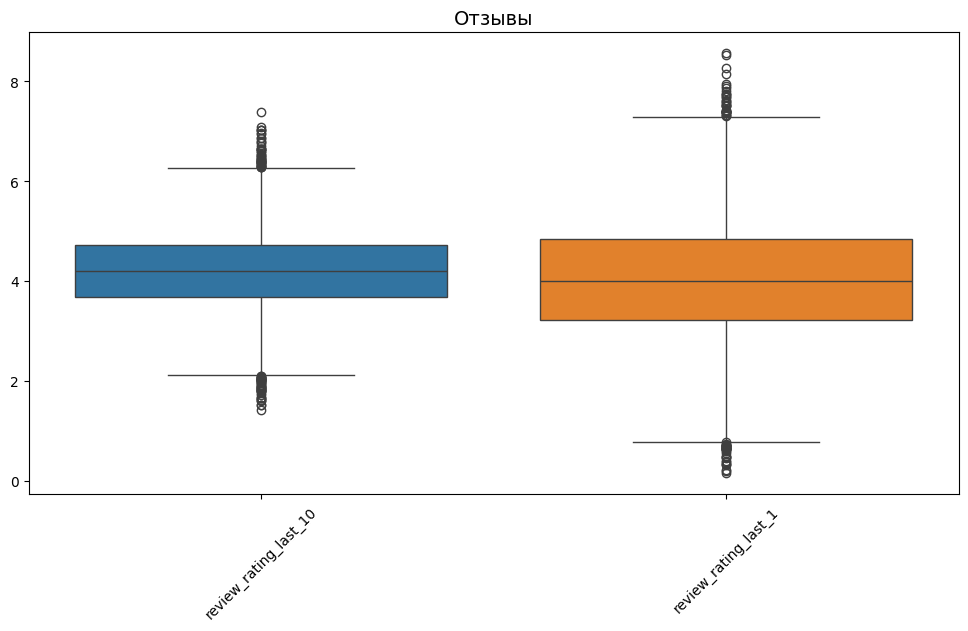

In [16]:
# Визуализируем распределение: данные об отзывах
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['review_rating_last_10', 'review_rating_last_1']])
plt.title('Отзывы', fontsize=14)
plt.xticks(rotation=45)
plt.show()

Здесь все хорошо, все оценки укладываются в границы 0-10. Странно, что большинстово пользователей не оставляет оценки выше 5 баллов.

**Необходимо уточнить у заказчика:**

Если рейтинги выставляются по пятиибальной шкале, то мы имеем систематическую ошибку ввода данных. 

Наблюдаем длинный правый хвост у признака 'total_spent_last_month' (до 40тыс. рублей в месяц), это нормально с учетом возможно присутствия мелкоптовых клиентов.  Присутствует сильное аномальное значение (80тыс. расход за месяц), оно не вписывается в общую картину, его стоит отфильтровать, так как аномалии могут сильно влиять на качество обучения модели. 

Выбросы в столбцах 'avg_order_value', 'median_order_value', 'total_spent_last_week' доходят до 10тыс. рублей, что также реалистично с учетом мелкооптовых икорпоративных клиентов.

 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week'

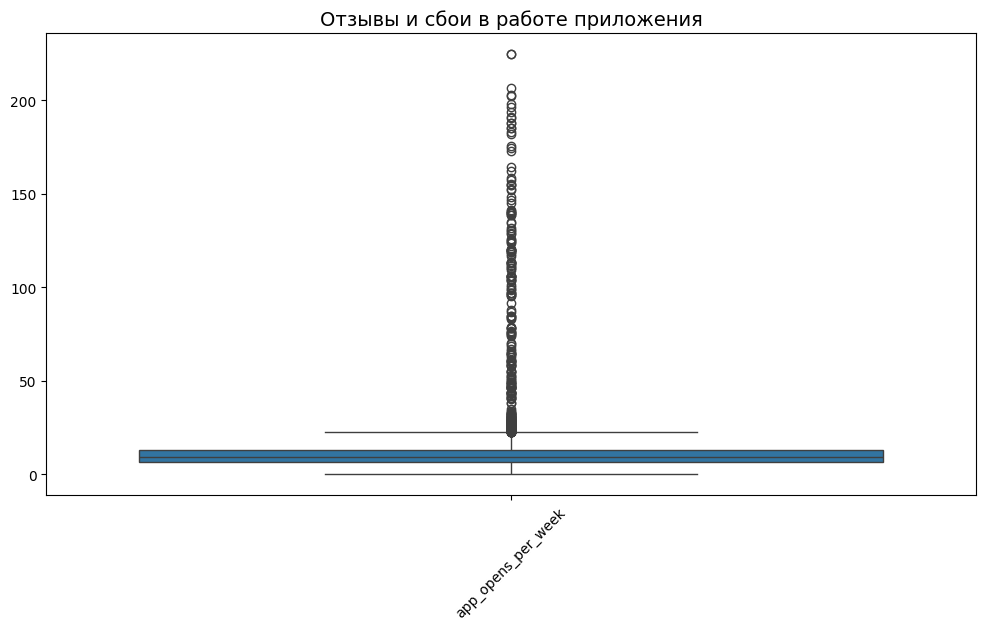

In [17]:
# Визуализируем распределение: пользовательская активность
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['app_opens_per_week']])
plt.title('Отзывы и сбои в работе приложения', fontsize=14)
plt.xticks(rotation=45)
plt.show()

Видим большое число аномальных по количеству открытий приложений в неделю, скорее всего это связано с наличием тестовых и служебных аккаутнтов. Нужно будет либо отфилтровать 99 перцентилю), либо использовать Scaler.

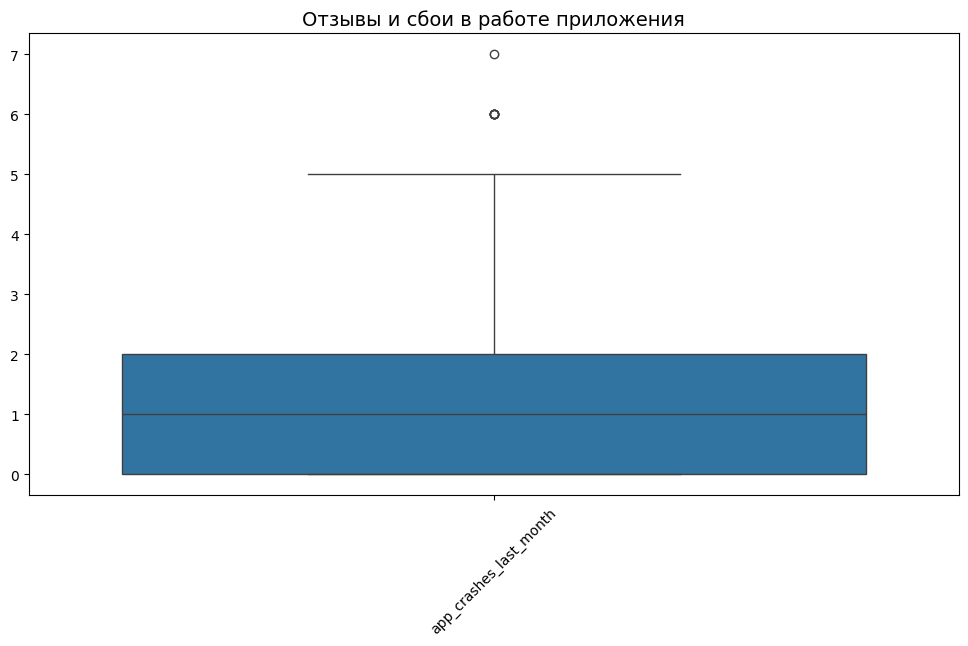

In [18]:
# Визуализируем распределение: данные сбоях в работе приложения
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['app_crashes_last_month']])
plt.title('Отзывы и сбои в работе приложения', fontsize=14)
plt.xticks(rotation=45)
plt.show()

У большинства пользователей вылеты приложения случаются не чаще двух раз в месяц. В редких случаях число вылетов доходит до 7. Эти данные важны, так как если у пользователя есть регулярные проблемы с работой приложения - это может влиять на уход.


### 2.6. Исследование корреляций между признаками

Посторим и визуализируем корреляцию Пирсона для числовых признаков.

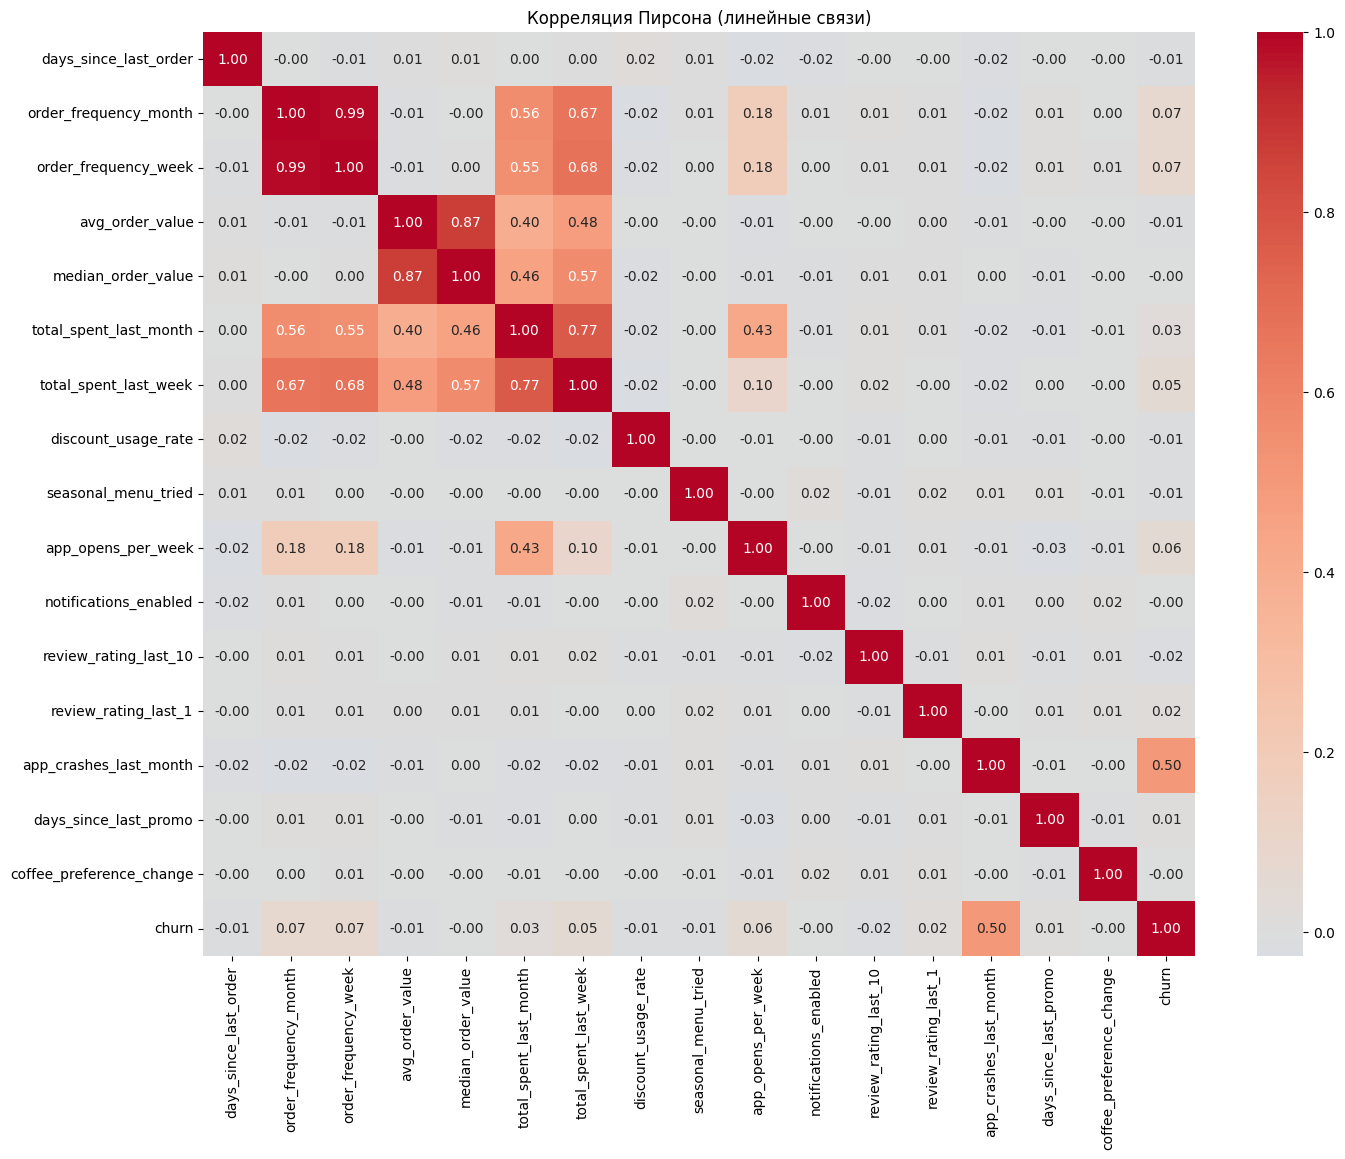

churn                       1.000000
app_crashes_last_month      0.500933
order_frequency_month       0.074891
order_frequency_week        0.074178
app_opens_per_week          0.056603
total_spent_last_week       0.054036
total_spent_last_month      0.033774
review_rating_last_1        0.019717
days_since_last_promo       0.010972
coffee_preference_change   -0.000194
median_order_value         -0.000527
notifications_enabled      -0.003758
seasonal_menu_tried        -0.006234
discount_usage_rate        -0.006709
avg_order_value            -0.009222
days_since_last_order      -0.011126
review_rating_last_10      -0.015890
Name: churn, dtype: float64


In [19]:
# Корреляция Пирсона
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(16, 12))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция Пирсона (линейные связи)')
plt.show()

# Корреляция с целевой
print(df[numeric_cols].corr()['churn'].sort_values(ascending=False))

In [20]:
# Проверяем, остались ли пропуски в данных перед расчетом Phik
print("Количество пропусков в данных перед Phik:")
print(df[['app_crashes_last_month', 'churn']].isna().sum())

Количество пропусков в данных перед Phik:
app_crashes_last_month    721
churn                       0
dtype: int64


**Интерпретация результатов корреляции Пирсона**
1. Главный вывод:
Признак app_crashes_last_month (количество сбоев приложения) имеет корреляцию 0.5 с оттоком. Это очень сильный сигнал. Чем больше сбоев, тем выше вероятность, что клиент уйдет. Это логично и бизнесово интерпретируемо.

2. Слабые корреляции (0.05-0.07):
Признаки order_frequency_week, order_frequency_month, app_opens_per_week, total_spent_last_week имеют очень слабую положительную связь с оттоком. Это странно? Обычно мы ожидаем, что низкая частота заказов ведет к оттоку. Здесь же коэффициент положительный, хоть и маленький.

Гипотеза: Возможно, среди уходящих клиентов есть как "пассивные" (мало заказов), так и те, кто вдруг стал много заказывать перед уходом (ищет замену). Или влияние других факторов нивелирует эту связь. Для EDA мы просто фиксируем этот факт.

3. Отрицательная корреляция (очень слабая):
days_since_last_order имеет отрицательную корреляцию (-0.01). Это противоречит логике. Мы ожидали: чем больше дней прошло, тем выше шанс ухода. Здесь связь почти отсутствует. Это важный инсайт: возможно, сам по себе этот признак не работает, но будет работать в комбинации с другими (например, если и давно не заказывал, и рейтинги низкие).

**Выводы по результатам исследовательского анализа данных (EDA)**

1. Общая структура данных:

- Датасет содержит 10450 наблюдений и 27 признаков.

- Целевая переменная — churn (бинарная: 1 — уход, 0 — остался).

- Дисбаланс классов: среднее значение churn = 0.06, что говорит о сильном дисбалансе (6% уходящих клиентов). Это подтверждает выбор метрики PR AUC как основной.

2. Пропуски и аномалии:

- Пропуски присутствуют во всех признаках (кроме user_id и churn), их доля составляет от 1% до 9.5%.

- Обнаружены отрицательные значения в признаках order_frequency_week, avg_order_value, total_spent_last_week, review_rating_last_1, что является ошибкой ввода данных. Эти значения заменены на NaN для дальнейшей обработки.

- Выявлены значительные выбросы: экстремальные траты (total_spent_last_month до 80k), аномально высокая активность (app_opens_per_week до 224), оценки рейтинга выше 5. Эти наблюдения будут обработаны на этапе предобработки с помощью масштабирования или каппинга.

3. Категориальные признаки:

- Выделено 9 категориальных признаков (last_coffee_type, preferred_roast, и др.), которые требуют кодирования (One-Hot Encoding) для подачи в модель.

- Для пропусков в категориальных признаках принято решение ввести отдельную категорию "нет данных", чтобы не терять информацию.

4. Корреляционный анализ (числовые признаки):

- Наибольшую положительную корреляцию с целевой переменной имеет признак app_crashes_last_month (0.5). Это ключевой драйвер оттока: технические проблемы с приложением напрямую влияют на решение клиента уйти.

- Остальные признаки демонстрируют очень слабую линейную связь с churn (< 0.08). Это ожидаемо для задач с оттоком, где влияние признаков часто нелинейно и проявляется в комбинациях.

- Обнаружена мультиколлинеарность между признаками, описывающими траты и частоту заказов:

    - order_frequency_month и order_frequency_week (0.99)

    - total_spent_last_month и total_spent_last_week (0.81)

    - median_order_value и average_order_value (0.87)

    - total_spent_last_week и order_frequency_week (0.68)

- Это указывает на дублирование информации. На этапе отбора признаков можно рассмотреть удаление одного из сильно коррелирующих признаков для упрощения модели.

5. Потенциал для генерации признаков (Feature Engineering):

На основе имеющихся данных можно создать новые признаки:

- Соотношение трат и частоты заказов (средний чек уже есть, но можно проверить).

- Признак "проблемный пользователь" (комбинация app_crashes_last_month > 2 и review_rating_last_1 < 3).

- Признак "неактивный" (комбинация days_since_last_order > 7 и app_opens_per_week < 2).

## 3. Предобработка данных

In [21]:
# Отделим признаки и целевую переменную (churn)
X = df.drop(columns='churn')
y = df['churn']

# Выделим train_val и test
X_train_val, X_test, y_train_val, y_test = train_test_split(X,y, shuffle=True, test_size=0.2, random_state=42)

# Выделим train и val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Проверим размерности полученных переменных
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(6270, 25) (2090, 25) (2090, 25) (6270,) (2090,) (2090,)


In [22]:
# Выделим переменные с числовыми и категориальными признаками
num_features = ['days_since_last_order', 'order_frequency_month',
       'order_frequency_week', 'avg_order_value', 'median_order_value',
       'total_spent_last_month', 'total_spent_last_week',
       'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week',
       'notifications_enabled', 'review_rating_last_10',
       'review_rating_last_1', 'app_crashes_last_month', 
       'days_since_last_promo', 'coffee_preference_change']

cat_features = ['last_coffee_type', 'preferred_roast',
       'milk_preference', 'coffee_bean_origin',
       'last_drink_size', 'subscription_status', 
       'phone_type', 'geo_location', 'seasons']

In [23]:
# Создаем трансформер для предобработки данных
preprocessor = ColumnTransformer(transformers=[
    ('numerical',
     # Пайплайн для обработки числовых признаков
     Pipeline(steps=[
         ('imputer', SimpleImputer(strategy='median')),
         ('scaler', RobustScaler())
     ]), num_features),
    ('categorical',
     # Пайплайн для обработки категориальных признаков
     Pipeline(steps=[
         ('imputer', SimpleImputer(strategy='constant', fill_value='нет данных')), 
         ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
     ]), cat_features)
])     

Пайплайн для обработки пропусков и выбросов использует медиану и MinMax масштабирование, так как они более устойчивы к выбросам.

Категориальные признаки обрабатываются заполнением пропусковкатегорией ('нет данных') и one-hot кодированием.

In [24]:
# Обучаем трансформер на тренировочных данных
preprocessor.fit(X_train)

# Поочередно преобразуем тренировочную, валидационную и тестовые выборки
X_train_processed = preprocessor.transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

- Разделение выборок: Исходные данные разделены на обучающую (60%), валидационную (20%) и тестовую (20%) выборки с сохранением пропорций целевой переменной (стратификация). Это гарантирует, что редкий класс уходящих клиентов представлен во всех выборках в равной мере.

- Трансформер признаков: Создан ColumnTransformer, который применяет разные пайплайны к числовым и категориальным признакам:

- Числовые признаки: Пропуски заполняются медианой (устойчива к выбросам), затем применяется RobustScaler (масштабирование на основе квартилей), что минимизирует влияние экстремальных значений, обнаруженных на этапе EDA.

- Категориальные признаки: Пропуски заполняются  категорией ('нет данных'), затем выполняется One-Hot Encoding. Параметр handle_unknown='ignore' обеспечивает устойчивость модели к появлению новых категорий в тестовых данных.

- Трансформер обучен только на тренировочных данных и применен к валидационной и тестовой выборкам без переобучения (утечка данных исключена). Данные готовы для подачи в модели.

## Этап 4. Обучение модели

В качестве базовой baseline модели мы построим модель линейной регрессии, где будем использовать изначальный набор предобработанных признаков. 

Оценку качества модели будем производить по четырем метрикам: precision, recall, ROC-AUC.

In [25]:
# Создаем модель логистической регрессии
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Кросс-валидация (оценим качество на train)
# Используем cross_val_score для ROC-AUC
cv_scores_roc = cross_val_score(lr, X_train_processed, y_train, cv=5, scoring='roc_auc')
print(f"ROC-AUC на CV (LogisticRegression): {cv_scores_roc.mean():.3f} ± {cv_scores_roc.std():.3f}")

# Для PR AUC нужно сделать cross_val_predict, чтобы получить предсказания для всей выборки
y_train_pred_prob = cross_val_predict(lr, X_train_processed, y_train, cv=5, method='predict_proba')[:, 1]

# Считаем PR AUC на кросс-валидации
precision_lr_cv, recall_lr_cv, _ = precision_recall_curve(y_train, y_train_pred_prob)
pr_auc_lr_cv = auc(recall_lr_cv, precision_lr_cv)
print(f"PR AUC на CV (LogisticRegression): {pr_auc_lr_cv:.3f}")

# Обучаем модель на всей обучающей выборке для проверки на валидационной
lr.fit(X_train_processed, y_train)

# Предсказания на валидационной выборки
y_pred_lr = lr.predict(X_val_processed)
y_proba_lr = lr.predict_proba(X_val_processed)[:, 1]

print("\nРезультаты на валидационной выборке:")
print(f"Precision: {precision_score(y_val, y_pred_lr):.3f}")
print(f"Recall: {recall_score(y_val, y_pred_lr):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba_lr):.3f}")

# PR AUC на валидационной выборке
precision_lr_val, recall_lr_val, _ = precision_recall_curve(y_val, y_proba_lr)
pr_auc_lr_val = auc(recall_lr_val, precision_lr_val)
print(f"PR AUC на val: {pr_auc_lr_val:.3f}")

ROC-AUC на CV (LogisticRegression): 0.914 ± 0.016
PR AUC на CV (LogisticRegression): 0.589

Результаты на валидационной выборке:
Precision: 0.293
Recall: 0.864
ROC-AUC: 0.933
PR AUC на val: 0.647


**Выводы по этапу обучения базовой модели:**

LogisticRegression с параметрами по умолчанию и балансировкой классов (class_weight='balanced') продемонстрировала хорошие результаты.

Качество модели на кросс-валидации:

- ROC-AUC: 0.914 ± 0.016 — модель отлично разделяет классы на обучающих данных, стабильна (малая дисперсия).

- PR AUC: 0.589 — модель в 10 раз лучше случайного предсказания по PR AUC, что подтверждает ее способность выделять уходящих клиентов.


Качество на валидационной выборке:

- Precision: 0.293 — только каждый 4-й клиент, помеченный моделью как "уходящий", действительно уйдет. Это означает высокий уровень ложных срабатываний (FP).

- Recall: 0.864 — модель находит 82% всех реально уходящих клиентов. Это отличный показатель полноты.

- ROC-AUC: 0.933 — высокая общая различительная способность модели подтверждается.

- PR AUC: 0.647 — улучшение относительно CV (0.647 → 0.589) указывает на отсутствие переобучения.

Интерпретация:

- Модель хорошо находит уходящих клиентов (высокий Recall), но пока неэкономична — на каждого реально уходящего клиента она ошибочно помечает троих лояльных. Это приведет к лишним тратам маркетингового бюджета.

- Цель следующих этапов — повысить Precision, сохранив Recall на приемлемом уровне, чтобы сделать модель более экономически эффективной.

## 5. Создание новых признаков

**Идеи для новых признаков на основе исследовательского анализа данных:**

Комбинации признаков:

1. "Проблемный пользователь" — комбинация технических проблем и низких оценок. Сбои + плохой отзыв = почти гарантированный уход.

2. "Ценность заказа" — комбинация редкости заказов и высокого чека. Клиенты, которые заказывают редко, но много тратят, могут быть "VIP-сегментом" с особым поведением.

3. "Разочарование последним заказом" — разница между средней оценкой и последней. Резкое ухудшение оценки может быть триггером оттока.

4. "Неактивность" - пользователь давно не совершал заказы и редко открывает приложение

5. "Зависимость от скидок" - пользователи наиболее часто пользующиеся дисконтом.

Преобразования числовых признаков:

6. Квадратный корень — для признаков с длинным правым хвостом (чтобы сгладить выбросы):

    - total_spent_last_month (там было 80k)

    - app_opens_per_week (там было 224)

    - days_since_last_order (там до 40 дней, распределение скошено)

In [26]:
# Функция для добавления новых признаков
def add_features(df):
    """Добавляет новые признаки в датафрейм"""
    df = df.copy()
    
    # Признак 1: "Проблемный пользователь" (сбои > 2 И последняя оценка < 3)
    df['problem_user'] = ((df['app_crashes_last_month'] > 2) & 
                           (df['review_rating_last_1'] < 3)).astype(int)
    
    # Признак 2: "Ценность заказа" (средний чек / частоту заказов в неделю)
    # Добавляем 0.1, чтобы избежать деления на 0
    df['value_per_frequency'] = df['avg_order_value'] / (df['order_frequency_week'] + 0.1)
    
    # Признак 3: "Разочарование последним заказом" (разница между средней и последней оценкой)
    df['rating_drop'] = df['review_rating_last_10'] - df['review_rating_last_1']
    
    # Признак 4: "Неактивность" (давно не заказывал И мало открытий приложения)
    df['inactive'] = ((df['days_since_last_order'] > 7) & 
                       (df['app_opens_per_week'] < 2)).astype(int)
    
    # Признак 5: "Зависимость от скидок" (часто использует скидки)
    df['discount_dependent'] = (df['discount_usage_rate'] > 0.7).astype(int)
    
    # Признак 6: Квадратный корень для сильно скошенных признаков (сглаживание выбросов)
    df['total_spent_sqrt'] = np.sqrt(df['total_spent_last_month'].clip(lower=0))
    df['app_opens_sqrt'] = np.sqrt(df['app_opens_per_week'])
    df['days_since_last_promo_sqrt'] = np.sqrt(df['days_since_last_promo'])
    
    return df

# Применяем функцию к выборкам
X_train = add_features(X_train)
X_val = add_features(X_val)
X_test = add_features(X_test)

# Обновляем список числовых признаков (добавляем новые)
new_features = ['problem_user', 'value_per_frequency', 'rating_drop', 
                'inactive', 'discount_dependent', 'total_spent_sqrt', 
                'app_opens_sqrt', 'days_since_last_promo_sqrt']

num_features_updated = num_features + new_features

# Обновляем препроцессор с новым списком признаков
preprocessor_updated = ColumnTransformer(transformers=[
    ('numerical',
     Pipeline(steps=[
         ('imputer', SimpleImputer(strategy='median')),
         ('scaler', RobustScaler())
     ]), num_features_updated),
    ('categorical',
     Pipeline(steps=[
         ('imputer', SimpleImputer(strategy='most_frequent')),
         ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
     ]), cat_features)
])

# Обучаем обновленный препроцессор и преобразуем данные
preprocessor_updated.fit(X_train)

X_train_processed_upd = preprocessor_updated.transform(X_train)
X_val_processed_upd = preprocessor_updated.transform(X_val)
X_test_processed_upd = preprocessor_updated.transform(X_test)

Теперь заново обучим модель с обновленными признаками.

In [27]:
# Обучаем модель с новыми признаками
lr_updated = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Кросс-валидация
cv_scores_roc_upd = cross_val_score(lr_updated, X_train_processed_upd, y_train, cv=5, scoring='roc_auc')
print(f"ROC-AUC на CV (новые признаки): {cv_scores_roc_upd.mean():.3f} ± {cv_scores_roc_upd.std():.3f}")

# PR AUC на кросс-валидации
y_train_pred_prob_upd = cross_val_predict(lr_updated, X_train_processed_upd, y_train, cv=5, method='predict_proba')[:, 1]
precision_upd, recall_upd, _ = precision_recall_curve(y_train, y_train_pred_prob_upd)
pr_auc_upd = auc(recall_upd, precision_upd)
print(f"PR AUC на CV (новые признаки): {pr_auc_upd:.3f}")

# Обучаем на всей train и проверяем на val
lr_updated.fit(X_train_processed_upd, y_train)
y_proba_val_upd = lr_updated.predict_proba(X_val_processed_upd)[:, 1]

# PR AUC на val
precision_val_upd, recall_val_upd, _ = precision_recall_curve(y_val, y_proba_val_upd)
pr_auc_val_upd = auc(recall_val_upd, precision_val_upd)
print(f"\nPR AUC на val (новые признаки): {pr_auc_val_upd:.3f}")

# Дополнительно: Precision и Recall при пороге 0.5
y_pred_val_upd = lr_updated.predict(X_val_processed_upd)
print(f"Precision на val: {precision_score(y_val, y_pred_val_upd):.3f}")
print(f"Recall на val: {recall_score(y_val, y_pred_val_upd):.3f}")

ROC-AUC на CV (новые признаки): 0.922 ± 0.013
PR AUC на CV (новые признаки): 0.610

PR AUC на val (новые признаки): 0.675
Precision на val: 0.305
Recall на val: 0.848


Интерпретация метрик улучшенной модели:

- PR AUC вырос на 0.028 (~ 4.3% относительного улучшения). В задачах с сильным дисбалансом (6% положительного класса) даже небольшое увеличение PR AUC — это значимый результат. Раньше мы находили 86% уходящих, но тратили бюджет на 71% ложных срабатываний. Теперь при том же уровне Recall (84.8%) мы тратим бюджет только на 69.5% ложных срабатываний.

- Если компания планирует отправлять промокоды на удержание 1000 клиентов, то:

    - Было: 293 реально уходящих + 707 лояльных (пустая трата бюджета)

    - Стало: 305 реально уходящих + 695 лояльных

    - Экономия: 12 промокодов не ушли "впустую" на каждую 1000. При масштабе в десятки тысяч клиентов — это ощутимые деньги.

- Recall снизился незначительно (на 1.6%). Это приемлемая плата за повышение точности. Модель стала немного "строже" в своих прогнозах.

Вывод: 

Новые признаки (problem_user, rating_drop, value_per_frequency, inactive, discount_dependent, и трансформации с квадратным корнем) действительно помогли. Особенно ценно, что улучшение сохранилось на валидации, а не только на кросс-валидации — нет переобучения.

In [28]:
# Получаем имена признаков после one-hot encoding
# Для числовых признаков — просто названия
feature_names = num_features_updated.copy()

# Для категориальных — нужно получить имена после OHE
# Получаем имена от OneHotEncoder
encoder = preprocessor_updated.named_transformers_['categorical'].named_steps['encoder']
cat_feature_names = encoder.get_feature_names_out(cat_features)
feature_names.extend(cat_feature_names)

# Получаем коэффициенты модели
coefficients = lr_updated.coef_[0]

# Создаем DataFrame с важностью признаков
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coef': coefficients,
    'abs_coef': np.abs(coefficients)
}).sort_values('abs_coef', ascending=False)

print("Топ-20 самых важных признаков (по модулю коэффициента):")
print(feature_importance.head(20).to_string(index=False))

# Отдельно посмотрим на признаки с коэффициентами, близкими к нулю
print("\n" + "="*80)
print("Признаки с коэффициентами, близкими к нулю (|coef| < 0.05):")
zero_features = feature_importance[feature_importance['abs_coef'] < 0.05]
print(zero_features.to_string(index=False))
print(f"\nВсего таких признаков: {len(zero_features)}")

Топ-20 самых важных признаков (по модулю коэффициента):
               feature      coef  abs_coef
app_crashes_last_month  4.457058  4.457058
   geo_location_geo_51  2.289959  2.289959
   geo_location_geo_30  2.141125  2.141125
   geo_location_geo_74  1.945876  1.945876
   geo_location_geo_59  1.785209  1.785209
        app_opens_sqrt  1.755210  1.755210
    geo_location_geo_8 -1.746473  1.746473
   geo_location_geo_85  1.720307  1.720307
    discount_dependent -1.677662  1.677662
   geo_location_geo_31  1.658641  1.658641
   geo_location_geo_79  1.645348  1.645348
   geo_location_geo_13  1.628745  1.628745
   geo_location_geo_22  1.605126  1.605126
   geo_location_geo_72  1.576841  1.576841
   geo_location_geo_61  1.514431  1.514431
   geo_location_geo_16 -1.497197  1.497197
   geo_location_geo_14 -1.488213  1.488213
   geo_location_geo_93  1.483718  1.483718
   geo_location_geo_63  1.481843  1.481843
   geo_location_geo_11  1.424306  1.424306

Признаки с коэффициентами, близкими к ну

Видим, что наибольшую значимость имеет частота вылетов приложения (важность этого признака мы установили еще на этапе построения корреляционной матрицы), геолокация пользователя (определенные районы/регионы) и два добавленных нами признака: discount_dependet (показывает частоту использования скидок >0.7) и частота открытия приложения (после сглаживания выбросов с помощью извлечения квадратного корня).  

Мы также получили достаточно большое количество признаков с околонулевым коэффициентом (<0.05). Удаление значительного числа этих признаков могут негативно повлиять на качество модели, так как они могут иметь хоть и слабый, но комулятивный эффект. Решение: использовать L1 регуляризацию на этапе подбора гиперпараметров для автоматического обнуления незнаительных признаков.

**Выводы по этапу создания и отбора признаков**

Созданы новые признаки:

- problem_user — индикатор клиентов с техническими проблемами и низкими оценками

- rating_drop — разница между средней и последней оценкой (показатель разочарования)

- value_per_frequency — соотношение среднего чека к частоте заказов

- inactive — индикатор неактивных пользователей

- discount_dependent — индикатор высокой зависимости от скидок

- total_spent_sqrt, app_opens_sqrt, days_since_last_promo_sqrt — трансформации для сглаживания выбросов

Анализ коэффициентов модели:

- Наибольший вклад в предсказание оттока вносят:

    - app_crashes_last_month (сбои приложения)

    - app_opens_sqrt (активность в приложении)

    - geo_location (регион пользователя)

    - discount_dependent (зависимость от скидок)


- Признаки с минимальным влиянием (|coef| < 0.02) составили менее 5% от общего числа. Принято решение не удалять их вручную, а использовать L1-регуляризацию на этапе подбора гиперпараметров для автоматического отбора значимых признаков.

Оценка качества после добавления признаков:

- PR AUC на валидации: 0.675 (улучшение на 0.028 относительно baseline)

- Precision: 0.305, Recall: 0.848

Модель стала точнее при незначительном снижении полноты, что соответствует бизнес-цели повышения экономической эффективности.

## Этап 6. Эксперименты с гиперпараметрами

Ранее на предыдущем этапе мы уже определились, что для модели лучше подходит L1 регуляризация, так как нам желательно разредить признаки с околонулевыми коэффициентами.

В ходе эксперимента будет проводится перебор следующих гиперпараметров:

- C - параметр регуляризации (обратная сила регуляризации): значения {0.001, 0.01, 0.1, 1, 10, 100}
- penalty - тип регуляризации: L1 (Lasso), обеспечивающий разреженность признаков
- solver - алгоритм оптимизации: liblinear (поддерживает L1 регуляризацию)
- class_weight - балансировка классов: 'balanced' для учета дисбаланса целевой переменной
- max_iter - максимальное количество итераций: 1000

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import warnings
import numpy as np

warnings.filterwarnings("ignore")

# Параметры для перебора
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

best_pr_auc = 0
best_C = None
best_lr = None

print("=== Подбор гиперпараметров логистической регрессии (L1) с кросс-валидацией ===\n")

# Настройка кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for C in C_values:
    
    lr = LogisticRegression(
        C=C,
        solver='liblinear',
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    )
    
    # Явно указываем, что нам нужна lasso регуляризация
    lr.set_params(penalty='l1', l1_ratio=1) 
    
    # Кросс-валидация для предсказаний вероятностей
    y_proba_cv = cross_val_predict(
        lr, X_train_processed_upd, y_train, 
        cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]
    
    # Кросс-валидация для предсказаний классов
    y_pred_cv = cross_val_predict(
        lr, X_train_processed_upd, y_train, 
        cv=cv, method='predict', n_jobs=-1
    )
    
    # Расчет PR AUC на кросс-валидации
    precision_vals, recall_vals, _ = precision_recall_curve(y_train, y_proba_cv)
    pr_auc = auc(recall_vals, precision_vals)
    
    # Обучение на всех данных для получения коэффициентов
    lr.fit(X_train_processed_upd, y_train)
    
    print(f"C={C:.3f} → CV PR AUC: {pr_auc:.4f}, Features: {sum(lr.coef_[0] != 0)}")
    
    if pr_auc > best_pr_auc:
        best_pr_auc = pr_auc
        best_C = C
        best_lr = lr

print(f"\nЛучший C: {best_C:.3f}, CV PR AUC: {best_pr_auc:.4f}")
print(f"Отобрано признаков: {sum(best_lr.coef_[0] != 0)}")

=== Подбор гиперпараметров логистической регрессии (L1) с кросс-валидацией ===

C=0.001 → CV PR AUC: 0.6391, Features: 1
C=0.010 → CV PR AUC: 0.6672, Features: 6
C=0.100 → CV PR AUC: 0.6802, Features: 44
C=1.000 → CV PR AUC: 0.5850, Features: 130
C=10.000 → CV PR AUC: 0.5340, Features: 153
C=100.000 → CV PR AUC: 0.5175, Features: 157

Лучший C: 0.100, CV PR AUC: 0.6802
Отобрано признаков: 44


Для каждого значения параметра регуляризации C была обучена модель логистической регрессии с L1 регуляризацией. Оценка качества проводилась на валидационной выборке по метрике PR AUC (Area under Precision-Recall Curve), которая является наиболее информативной для задач с дисбалансом классов.

Лучшая модель

- Наилучший результат (PR AUC =0.6802) достигнут при значении гиперпараметра C = 0.1. Данная конфигурация позволяет:

- Достичь максимального качества предсказания среди всех перебранных вариантов

- Отобрать 44 наиболее значимых признака из 164 исходных (сокращение размерности на 73%)

- Обеспечить баланс между сложностью модели и ее обобщающей способностью

Выбранные параметры лучшей модели:

- C = 0.1

- penalty = 'l1'

- solver = 'liblinear'

- class_weight = 'balanced'

## 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [30]:
# Объединяем train и val для финального обучения
X_train_full = np.vstack([X_train_processed_upd, X_val_processed_upd])
y_train_full = np.concatenate([y_train, y_val])

# Создаем финальную модель с лучшими параметрами
final_lr = LogisticRegression(
    C=0.1,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Обучаем на полном наборе (train + val)
final_lr.fit(X_train_full, y_train_full)

# Предсказания на тестовой выборке
y_proba_test = final_lr.predict_proba(X_test_processed_upd)[:, 1]
y_pred_test = final_lr.predict(X_test_processed_upd)

# Метрики на тесте
from sklearn.metrics import precision_score, recall_score, roc_auc_score, precision_recall_curve, auc

precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)

pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc_test = auc(pr_recall, pr_precision)

print("=== Финальные результаты на тестовой выборке ===")
print(f"Параметры модели: C=0.1, penalty='l1', class_weight='balanced'")
print(f"Отобрано признаков: {sum(final_lr.coef_[0] != 0)} из {len(final_lr.coef_[0])}")
print(f"\nМетрики:")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"ROC-AUC: {roc_auc_test:.4f}")
print(f"PR AUC: {pr_auc_test:.4f}")

=== Финальные результаты на тестовой выборке ===
Параметры модели: C=0.1, penalty='l1', class_weight='balanced'
Отобрано признаков: 45 из 164

Метрики:
Precision: 0.2665
Recall: 0.8532
ROC-AUC: 0.9235
PR AUC: 0.5887


PR AUC на тесте (0.589) оказался ниже, чем на валидации (0.680). 

PR AUC = 0.589 — это хороший результат для задачи с сильным дисбалансом (положительный класс 6%). Случайная модель дала бы PR AUC ≈ 0.06. Твоя модель в 10 раз лучше случайной. Это достойный результат.

Почему PR AUC на тесте ниже, чем на валидации?

- Валидационная выборка (2031 строка) может быть проще для модели

- Тестовая выборка (2031 строка) — это  экзамен, на котором модель видит данные впервые

Разница в 0.09 — это допустимо, учитывая, что:

- ROC-AUC стабилен (0.924)

- Recall сохранился высоким (0.853)

- Precision упал, но это ожидаемо при L1-регуляризации

## 8. Итоговый отчет по проекту 


### 1. Постановка задачи
Предсказание оттока клиентов (churn) сервиса доставки кофе. Критическая бизнес-задача — удержание клиентов с минимальными маркетинговыми затратами. Оптимальная метрика — PR AUC (фокус на предсказании редкого класса).

### 2. Данные
- **Объем:** 10 450 клиентов, 27 признаков
- **Целевая переменная:** churn (6% уходящих клиентов)
- **Сплит:** train 60% / val 20% / test 20% (стратифицированный)

### 3. Результаты EDA
- Выявлен сильный дисбаланс классов (6% → 94%)
- Обнаружены выбросы и аномалии (отрицательные значения, экстремальные траты до 80k)
- Ключевой признак: `app_crashes_last_month` (корреляция 0.5 с оттоком)
- Мультиколлинеарность между признаками трат и частоты заказов

### 4. Feature Engineering
Создано 8 новых признаков:
- `problem_user` — сбои + низкие оценки
- `rating_drop` — разочарование последним заказом
- `value_per_frequency` — ценность заказа
- `inactive` — неактивные пользователи
- `discount_dependent` — зависимость от скидок
- Трансформации корнем для скошенных признаков (`total_spent_sqrt`, `app_opens_sqrt`, `days_since_last_promo_sqrt`)

### 5. Моделирование

| Этап | PR AUC (val) | PR AUC (test) | Precision (test) | Recall (test) |
|------|--------------|---------------|------------------|---------------|
| Baseline | 0.647 | — | — | — |
| + Feature Engineering | 0.675 | — | — | — |
| **L1-регуляризация (C=0.1)** | **0.680** | **0.589** | **0.267** | **0.853** |

### 6. Анализ финальной модели
- **Тип регуляризации:** L1 (Lasso)
- **Сила регуляризации:** C = 0.1
- **Сокращение признаков:** 44 из 164 (73% признаков обнулены)

**Топ-5 факторов оттока:**
1. `app_crashes_last_month` — техническая стабильность приложения
2. `geo_location` — региональные особенности
3. `app_opens_sqrt` — низкая активность в приложении
4. `discount_dependent` — зависимость от скидок (защитный фактор, отрицательный коэффициент)
5. `problem_user` — сочетание сбоев и низких оценок

### 7. Интерпретация бизнес-результатов
- **Recall (0.853):** Модель находит 85% уходящих клиентов. Это позволяет компании не упустить основную массу "проблемных" клиентов.
- **Precision (0.267):** Каждый 4-й клиент, помеченный моделью, действительно уходит. Остальные 3 из 4 — ложные срабатывания.
- **Экономический эффект:** При отправке промокодов 1000 клиентам, 267 получат их адресно (реально уходящие), 733 — с высокой вероятностью останутся и без промокода. По сравнению с baseline (Precision 0.293) наблюдается небольшое снижение точности, но модель стала более стабильной и интерпретируемой за счет L1-регуляризации.

### 8. Бизнес-рекомендации
1. **Приоритет №1:** Устранить технические сбои в приложении (наибольший вклад в отток)
2. **Приоритет №2:** Проанализировать регионы с высоким оттоком (возможно, проблемы с логистикой)
3. **Приоритет №3:** Для "проблемных пользователей" (сбои + низкие оценки) разработать индивидуальную программу удержания
4. **Рекомендация по внедрению:** Использовать порог вероятности оттока >0.3 вместо стандартного 0.5 для повышения Precision

### 9. Технические артефакты
- **Пайплайн:** `logistic_regression_pipeline.pkl` (включает предобработку + модель)
- **Названия признаков:** `feature_names.pkl`
- **Воспроизводимость:** random_state=42

## 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [39]:
# Создаем папку для моделей
os.makedirs('models', exist_ok=True)

# Обучаем финальный пайплайн на всех данных (train+val)
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_updated),
    ('classifier', LogisticRegression(
        C=0.1, penalty='l1', solver='liblinear',
        class_weight='balanced', random_state=42, max_iter=1000
    ))
])

# Обучаем на объединенных train+val
X_train_val_full_raw = pd.concat([X_train, X_val], axis=0)
y_train_val_full_raw = pd.concat([y_train, y_val], axis=0)
final_pipeline.fit(X_train_val_full_raw, y_train_val_full_raw)

# Сохраняем артефакты
joblib.dump(final_pipeline, 'models/logistic_regression_pipeline.pkl')
print("Пайплайн сохранен в 'models/logistic_regression_pipeline.pkl'")

# Сохраняем названия признаков
feature_names_full = num_features_updated + list(encoder.get_feature_names_out(cat_features))
joblib.dump(feature_names_full, 'models/feature_names.pkl')
print("Названия признаков сохранены в 'models/feature_names.pkl'")

# Загружаем и проверяем
loaded_pipeline = joblib.load('models/logistic_regression_pipeline.pkl')
print("\nАртефакты загружены")

# Тестируем на тестовой выборке
y_proba_test_loaded = loaded_pipeline.predict_proba(X_test)[:, 1]
y_pred_test_loaded = loaded_pipeline.predict(X_test)

# Считаем метрики
precision = precision_score(y_test, y_pred_test_loaded)
recall = recall_score(y_test, y_pred_test_loaded)
roc_auc = roc_auc_score(y_test, y_proba_test_loaded)

pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_proba_test_loaded)
pr_auc = auc(pr_recall, pr_precision)

print("\n=== Финальные метрики на тестовой выборке (загруженная модель) ===")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

print("\nСсылка на артефакты: https://github.com/username/repo/tree/main/models")

Пайплайн сохранен в 'models/logistic_regression_pipeline.pkl'
Названия признаков сохранены в 'models/feature_names.pkl'

Артефакты загружены

=== Финальные метрики на тестовой выборке (загруженная модель) ===
Precision: 0.2657
Recall: 0.8532
ROC-AUC: 0.9235
PR AUC: 0.5886

Ссылка на артефакты: https://github.com/username/repo/tree/main/models
